# Ejemplo: Estabilidad de Lyapunov para el péndulo invertido

In [14]:
import sympy as sp
sp.init_printing() #esto hace que las expresiones se vean bonitas en la salida de la consola 

## Creamos las variables simbólicas necesarias y definimos las ecuaciones del sistema

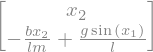

In [15]:
x1, x2, m, l, g, b = sp.symbols('x1 x2 m l g b', real=True)

f = sp.Matrix([
    x2,
    g/l*sp.sin(x1) - b/m/l*x2
])
f

Aunque $(0,0)$ es un punto de equilibrio del sistema, vamos a estudiar directamente la estabilidad en un punto del que sabemos que sí es estable $(\pi, 0)$. Para ello hacemos un cambio de variable: $z_1 = x_1 - \pi$, $z_2 = x_2$.

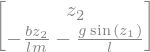

In [16]:
z1, z2 = sp.symbols('z1 z2', real=True)

f_z = sp.Matrix([
    z2,
    g/l*sp.sin(z1 - sp.pi) - b/m/l*z2
])
f_z

## Función candidata de Lyapunov 1: Energía del sistema

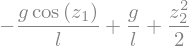

In [17]:
V = sp.Rational(1,2)*z2**2 + g/l*sp.cos(z1 - sp.pi) + g/l #ojo no dividir directamente 1/2 
V

Calculamos el gradiente de $V$ y la derivada de Lie.

> **Nota:** `sympy` no tiene una función `gradient` de propósito general como MATLAB para un caso tan simple; el gradiente de un campo escalar se construye directamente derivando respecto a cada variable con `sp.diff`. Además, empleo display para mostrar el gradiente con formato 'bonito' se puede usar print pero entonces sale una expresión estándar de python. No puedo limitarme a escribir grv.T ya que jupyter notes solo imprime la última expresion de una celda. si hay dos seguidas, no imprime la primera :(


'grad(V) ='

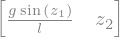

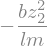

In [18]:
grv = sp.Matrix([sp.diff(V, z1), sp.diff(V, z2)])   # gradiente de V
dlee = sp.simplify((grv.T * f_z)[0, 0])              # derivada de Lie: grad(V) . f_z
display('grad(V) =', grv.T) #uso display para que se vea bonito en la salida de la consola
dlee

Luego el punto $z=(0,0) \equiv x=(\pi,0)$ es estable ya que $\dot V \leq 0$. Sin embargo, no es asintóticamente estable, $\dot V$ es solo semidefinida negativa.

## Función candidata de Lyapunov 2: Forma cuadrática definida positiva

Cambiamos la función de Lyapunov de modo que ahora tome la forma de una función cuadrática.
>**Nota** Al construir V2 empleamos (zvec.T * P * zvec)[0, 0], porque por defecto la operación devuelve una matriz de dimension 1x1, lo que hacemos pidiendo el elemento [0,0] es extraer su único elemento, como un escalar.


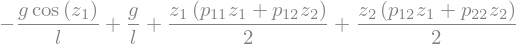

In [19]:
p11, p12, p22 = sp.symbols('p11 p12 p22', real=True)

P = sp.Matrix([[p11, p12],
               [p12, p22]])

zvec = sp.Matrix([z1, z2])
V2 = sp.Rational(1,2) * (zvec.T * P * zvec)[0, 0] + g/l*sp.cos(z1 - sp.pi) + g/l
V2

Calculamos el gradiente de $V_2$ y la derivada de Lie,

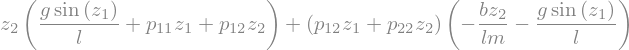

In [20]:
grv2 = sp.Matrix([sp.diff(V2, z1), sp.diff(V2, z2)])
dlee2 = (grv2.T * f_z)[0, 0]
dlee2

Sacamos factor común a $z_1$ y $z_2$, para ver un poco más clara la expresión,

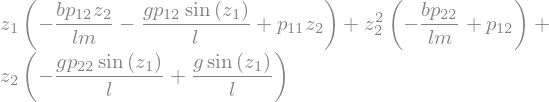

In [21]:
dlee2 = sp.collect(sp.expand(dlee2), [z1,z2])
dlee2

Si elegimos $p_{22}=1$ y $p_{11}=\dfrac{b\,p_{12}}{lm}$, eliminamos los términos cruzados que tienen signo indefinido.

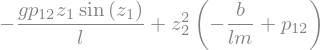

In [22]:
dlee2 = dlee2.subs(p22, 1)
dlee2 = dlee2.subs(p11, b*p12/l/m)
dlee2

Necesitamos imponer una última condición en $p_{12}$ para asegurar que $P$ es definida positiva.

$p_{11} > 0$ para asegurar que $p_{12}$ también lo es. Además, necesitamos que $\det(P) > 0$.

P =


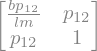

det(P) =


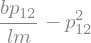

In [23]:
P = P.subs([(p22, 1), (p11, b*p12/l/m)])
dP = P.det()
print('P =')
display(P)
print('det(P) =')
sp.simplify(dP)

Bastaría tomar por ejemplo $p_{12} = \dfrac{b}{2lm}$.

P =


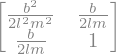

V =


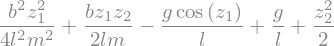

dlee2 =


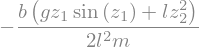

In [24]:
P = P.subs(p12, b/2/l/m)
V = (zvec.T * P * zvec)[0, 0] / 2 + g/l*sp.cos(z1 - sp.pi) + g/l
dlee2 = dlee2.subs(p12, b/2/l/m)

print('P =')
display(P)
print('V =')
display(sp.simplify(V))
print('dlee2 =')
sp.simplify(dlee2)

En este caso tendríamos una función definida negativa para la derivada de Lie, y por tanto podríamos decir que el péndulo invertido es asintóticamente estable en un entorno de $\pi$. Además sabemos que la condición se cumple para $|x_1| < \pi$, puesto que en $(\pi,0)$ y $(-\pi,0)$ la derivada de Lie se anula. Por tanto, no podemos concluir que el punto sea asintóticamente estable de modo global. (De hecho sabemos que no lo es).